# Problemas de repaso - Parcial 2

## Machine Learning

En el presente desarrollo se aplican los modelos de regresión Ridge, Lasso y Red Elástica utilizando la misma metodología trabajada en las clases y ejemplos vistos previamente.

In [2]:

import pandas as pd
import os
import tarfile
import urllib.request
import numpy as np
from pandas.core.common import flatten
from plotnine import *
from array import *
import scipy.stats as stats
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms


# Ejercicio 1

En este ejercicio se analizará el comportamiento del precio de acciones utilizando modelos de regresión penalizada.  

El objetivo es identificar cuál de los métodos de regresión presenta el mejor comportamiento predictivo utilizando los modelos:
- Ridge
- Lasso
- Red Elástica


In [3]:

#Cargar base de datos
datos = pd.read_csv("Acciones.csv")

#Mostrar datos
datos


,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-06-18,107.010002,107.209999,104.830002,105.379997,91.337906,5964400
1,2018-06-19,105.489998,106.680000,105.220001,105.959999,91.840607,5504400
2,2018-06-20,105.730003,106.110001,105.360001,105.809998,91.710587,4601400
3,2018-06-21,106.570000,107.430000,106.300003,107.239998,92.950027,6550700
4,2018-06-22,107.239998,108.669998,107.139999,108.370003,93.929474,5709400
...,...,...,...,...,...,...,...
1253,2023-06-09,181.710007,182.830002,181.000000,182.350006,182.350006,3200100
1254,2023-06-12,182.490005,182.729996,180.690002,181.899994,181.899994,4207100
1255,2023-06-13,182.130005,182.190002,181.080002,181.539993,181.539993,2838700
1256,2023-06-14,182.000000,183.649994,181.440002,183.169998,183.169998,3559300


In [4]:
#Información de las variables
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1258 non-null   str    
 1   Open       1258 non-null   float64
 2   High       1258 non-null   float64
 3   Low        1258 non-null   float64
 4   Close      1258 non-null   float64
 5   Adj Close  1258 non-null   float64
 6   Volume     1258 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 81.2 KB


In [5]:
#Estadísticos descriptivos
datos.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,145.949452,147.080548,144.736542,145.957655,136.777506,4.825560e+06
std,22.641339,22.689665,22.522826,22.629489,26.568257,2.057820e+06
min,105.199997,105.760002,101.419998,103.930000,91.337906,8.833000e+05
25%,131.564999,132.679993,130.244995,131.425003,119.144336,3.621125e+06
50%,141.659996,143.035004,140.809998,141.845002,130.979248,4.424550e+06
75%,167.502495,168.794999,165.505001,167.402504,162.282551,5.499875e+06
max,196.570007,196.880005,194.949997,196.119995,194.759476,2.755970e+07


In [6]:
#Primeras observaciones
datos.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-06-18,107.010002,107.209999,104.830002,105.379997,91.337906,5964400
1,2018-06-19,105.489998,106.680000,105.220001,105.959999,91.840607,5504400
2,2018-06-20,105.730003,106.110001,105.360001,105.809998,91.710587,4601400
3,2018-06-21,106.570000,107.430000,106.300003,107.239998,92.950027,6550700
4,2018-06-22,107.239998,108.669998,107.139999,108.370003,93.929474,5709400


In [7]:
#Últimas observaciones
datos.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
1253,2023-06-09,181.710007,182.830002,181.000000,182.350006,182.350006,3200100
1254,2023-06-12,182.490005,182.729996,180.690002,181.899994,181.899994,4207100
1255,2023-06-13,182.130005,182.190002,181.080002,181.539993,181.539993,2838700
1256,2023-06-14,182.000000,183.649994,181.440002,183.169998,183.169998,3559300
1257,2023-06-15,184.259995,186.169998,183.520004,185.710007,185.710007,4326100


A continuación se realizará un análisis gráfico de las variables del conjunto de datos para observar el comportamiento general de los precios y el volumen de transacciones.

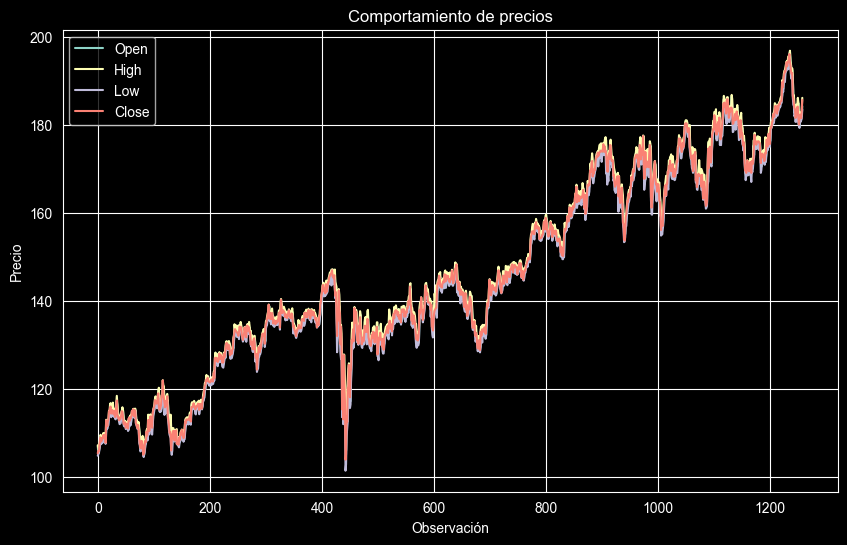

In [8]:

fig = plt.figure(figsize=(10,6))

plt.plot(datos["Open"], label = "Open")
plt.plot(datos["High"], label = "High")
plt.plot(datos["Low"], label = "Low")
plt.plot(datos["Close"], label = "Close")

plt.xlabel("Observación")
plt.ylabel("Precio")
plt.title("Comportamiento de precios")
plt.legend()
plt.show(fig)


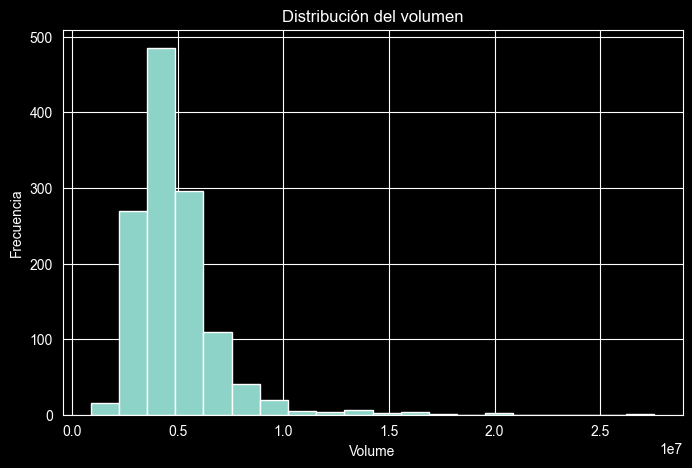

In [9]:

fig = plt.figure(figsize=(8,5))

plt.hist(datos["Volume"], bins = 20)

plt.xlabel("Volume")
plt.ylabel("Frecuencia")
plt.title("Distribución del volumen")
plt.show(fig)


In [10]:

#Separar variable respuesta y predictoras
respuesta = datos["Close"].copy()

predictoras = datos.drop(["Date", "Close"], axis = 1)

predictoras.head()


,Open,High,Low,Adj Close,Volume
0,107.010002,107.209999,104.830002,91.337906,5964400
1,105.489998,106.680000,105.220001,91.840607,5504400
2,105.730003,106.110001,105.360001,91.710587,4601400
3,106.570000,107.430000,106.300003,92.950027,6550700
4,107.239998,108.669998,107.139999,93.929474,5709400


In [11]:

#Estandarizar variables
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(predictoras)

predictoras_est = pd.DataFrame(scaler.transform(predictoras),
                              columns = predictoras.columns)

predictoras_est


,Open,High,Low,Adj Close,Volume
0,-1.720523,-1.757911,-1.772531,-1.710977,0.553641
1,-1.787683,-1.781279,-1.755209,-1.692048,0.330014
2,-1.777079,-1.806410,-1.748990,-1.696944,-0.108974
3,-1.739964,-1.748211,-1.707238,-1.650274,0.838667
4,-1.710360,-1.693539,-1.669928,-1.613394,0.429674
...,...,...,...,...,...
1253,1.580065,1.576210,1.610716,1.715981,-0.790208
1254,1.614528,1.571800,1.596947,1.699036,-0.300661
1255,1.598622,1.547992,1.614270,1.685481,-0.965901
1256,1.592878,1.612364,1.630260,1.746857,-0.615585


In [12]:

#Dividir datos entrenamiento y validación
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(predictoras_est,
                                                    respuesta,
                                                    test_size = 0.25,
                                                    random_state = 2026)


## Regresión Ridge

Se aplicará la regresión Ridge utilizando distintos valores de regularización para observar cómo cambian los coeficientes y el error cuadrático medio.

In [13]:

#Importar clase
from sklearn.linear_model import Ridge

#Modelo Ridge alpha = 1
ridge_reg = Ridge(alpha = 1, solver = "auto")

ridge_reg.fit(X_train, y_train)

print("El intercepto que se tiene es %s" %ridge_reg.intercept_)

coefs_ridge_a = pd.DataFrame({"Variables": predictoras.columns,
                              "Coeficientes": ridge_reg.coef_})

coefs_ridge_a


El intercepto que se tiene es 145.9494361203447


,Variables,Coeficientes
0,Open,-1.690230
1,High,7.419330
2,Low,10.968810
3,Adj Close,5.909145
4,Volume,-0.092790


In [14]:

#Modelo Ridge alpha = 1000
ridge_reg_b = Ridge(alpha = 1000, solver = "auto")

ridge_reg_b.fit(X_train, y_train)

print("El intercepto que se tiene es %s" %ridge_reg_b.intercept_)

coefs_ridge_b = pd.DataFrame({"Variables": predictoras.columns,
                              "Coeficientes": ridge_reg_b.coef_})

coefs_ridge_b


El intercepto que se tiene es 145.85116678472656


,Variables,Coeficientes
0,Open,4.432305
1,High,4.450696
2,Low,4.453915
3,Adj Close,4.449151
4,Volume,-0.289930


In [15]:

#Modelo lineal
from sklearn.linear_model import LinearRegression

lm = LinearRegression()

lm.fit(X_train, y_train)

#Predicciones
y_pred_lm = lm.predict(X_test)

y_pred_ridge = ridge_reg.predict(X_test)

y_pred_ridge_b = ridge_reg_b.predict(X_test)

#Errores
mse_lm = mean_squared_error(y_test, y_pred_lm)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)

mse_ridge_b = mean_squared_error(y_test, y_pred_ridge_b)

errores_ridge = [mse_lm, mse_ridge, mse_ridge_b]

comparacion_ridge = pd.DataFrame({"Modelo": ["Lineal",
                                            r"Ridge $alpha=1$",
                                            r"Ridge $alpha=1000$"],
                                 "MSE": errores_ridge})

comparacion_ridge


,Modelo,MSE
0,Lineal,0.431810
1,Ridge $alpha=1$,0.605339
2,Ridge $alpha=1000$,25.247723


El comportamiento de los modelos Ridge permite observar cómo la penalización afecta directamente los coeficientes de regresión.  

Cuando el valor de alpha aumenta considerablemente, los coeficientes tienden a encogerse, reduciendo la complejidad del modelo. Sin embargo, una penalización excesiva puede provocar pérdida de capacidad predictiva y aumentar el error cuadrático medio.


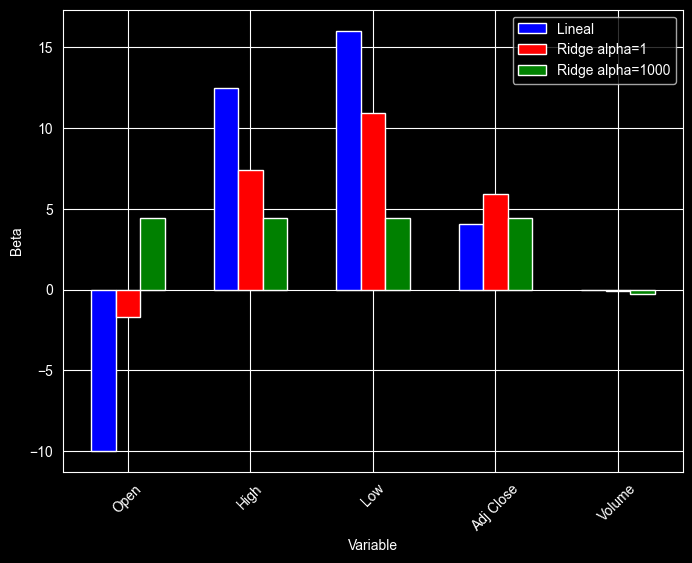

In [16]:

fig = plt.figure(figsize=(8,6))

barWidth = 0.20

r1 = np.arange(len(lm.coef_))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]

plt.bar(r1, lm.coef_, color = "blue",
       width = barWidth,
       edgecolor = "white",
       label = "Lineal")

plt.bar(r2, ridge_reg.coef_, color = "red",
       width = barWidth,
       edgecolor = "white",
       label = "Ridge alpha=1")

plt.bar(r3, ridge_reg_b.coef_, color = "green",
       width = barWidth,
       edgecolor = "white",
       label = "Ridge alpha=1000")

plt.xticks([r + barWidth for r in range(len(lm.coef_))],
          [predictoras.columns[i] for i in range(len(predictoras.columns))],
          rotation = 45)

plt.legend()
plt.xlabel("Variable")
plt.ylabel("Beta")
plt.show(fig)


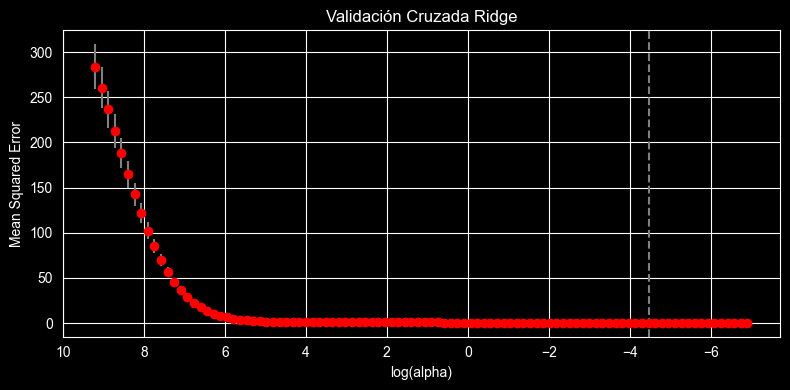

El valor de alpha que minimiza el mse es 0.011497569953977356


In [17]:

from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_score

alphas = np.logspace(-3, 4, 100)

ridge = RidgeCV(alphas = alphas, cv = 10)

ridge.fit(X_train, y_train)

kf = KFold(n_splits = 10,
          shuffle = True,
          random_state = 2026)

mse_mean = list()
mse_std = list()

for alpha in alphas:

    modelo_tmp = RidgeCV(alphas = [alpha], cv = None)

    scores = cross_val_score(modelo_tmp,
                            X_train,
                            y_train,
                            scoring = 'neg_mean_squared_error',
                            cv = kf)

    mse = -scores

    mse_mean.append(mse.mean())
    mse_std.append(mse.std())

mse_mean = np.array(mse_mean)
mse_std = np.array(mse_std)

alpha_min_ridge = ridge.alpha_

idx_min = np.argmin(mse_mean)

mse_min = mse_mean[idx_min]

se_min = mse_std[idx_min]

idx_1se = np.where(mse_mean <= mse_min + se_min)[0][0]

alpha_1se = alphas[idx_1se]

x = np.log(alphas)

plt.figure(figsize=(8,4))

plt.errorbar(x,
            mse_mean,
            yerr = mse_std,
            fmt = 'o',
            color = 'red',
            ecolor = 'gray')

plt.axvline(np.log(alpha_min_ridge),
           linestyle = '--',
           color = "gray")

plt.xlabel("log(alpha)")
plt.ylabel("Mean Squared Error")
plt.title("Validación Cruzada Ridge")

plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

print("El valor de alpha que minimiza el mse es %s" %alpha_min_ridge)


## Regresión Lasso

La regresión Lasso permite además realizar selección de variables, ya que algunos coeficientes pueden reducirse hasta cero dependiendo del nivel de penalización aplicado.

In [18]:

from sklearn.linear_model import Lasso

#Modelo Lasso alpha = 1
lasso_reg = Lasso(alpha = 1)

lasso_reg.fit(X_train, y_train)

print("El intercepto que se tiene es %s" %lasso_reg.intercept_)

coefs_lasso_a = pd.DataFrame({"Variables": predictoras.columns,
                             "Coeficientes": lasso_reg.coef_})

coefs_lasso_a


El intercepto que se tiene es 145.92810750808906


,Variables,Coeficientes
0,Open,0.000000
1,High,5.521301
2,Low,11.766439
3,Adj Close,4.318898
4,Volume,-0.000000


In [19]:

#Modelo Lasso alpha = 10
lasso_reg_b = Lasso(alpha = 10)

lasso_reg_b.fit(X_train, y_train)

print("El intercepto que se tiene es %s" %lasso_reg_b.intercept_)

coefs_lasso_b = pd.DataFrame({"Variables": predictoras.columns,
                             "Coeficientes": lasso_reg_b.coef_})

coefs_lasso_b


El intercepto que se tiene es 145.75050195709645


,Variables,Coeficientes
0,Open,0.000000
1,High,5.098661
2,Low,7.333147
3,Adj Close,0.000000
4,Volume,-0.000000


In [20]:

#Predicciones
y_pred_lasso = lasso_reg.predict(X_test)

y_pred_lasso_b = lasso_reg_b.predict(X_test)

#Errores
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

mse_lasso_b = mean_squared_error(y_test, y_pred_lasso_b)

errores_lasso = [mse_lm, mse_lasso, mse_lasso_b]

comparacion_lasso = pd.DataFrame({"Modelo": ["Lineal",
                                            r"Lasso $alpha=1$",
                                            r"Lasso $alpha=10$"],
                                 "MSE": errores_lasso})

comparacion_lasso


,Modelo,MSE
0,Lineal,0.431810
1,Lasso $alpha=1$,1.813980
2,Lasso $alpha=10$,110.011656


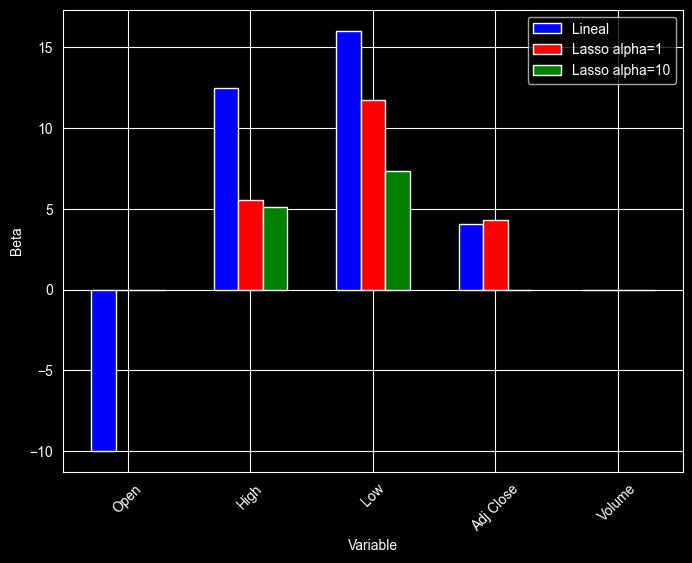

In [21]:

fig = plt.figure(figsize=(8,6))

barWidth = 0.20

r1 = np.arange(len(lm.coef_))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]

plt.bar(r1, lm.coef_, color = "blue",
       width = barWidth,
       edgecolor = "white",
       label = "Lineal")

plt.bar(r2, lasso_reg.coef_, color = "red",
       width = barWidth,
       edgecolor = "white",
       label = "Lasso alpha=1")

plt.bar(r3, lasso_reg_b.coef_, color = "green",
       width = barWidth,
       edgecolor = "white",
       label = "Lasso alpha=10")

plt.xticks([r + barWidth for r in range(len(lm.coef_))],
          [predictoras.columns[i] for i in range(len(predictoras.columns))],
          rotation = 45)

plt.legend()
plt.xlabel("Variable")
plt.ylabel("Beta")
plt.show(fig)


In [22]:

from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(alphas = alphas, cv = 10)

lasso_cv.fit(X_train, y_train)

print("El valor de alpha que minimiza el mse es %s" %lasso_cv.alpha_)


El valor de alpha que minimiza el mse es 0.001


C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.167e+02, tolerance: 4.743e+01


## Red Elástica

Finalmente se realizará el modelo de Red Elástica combinando las penalizaciones de Ridge y Lasso.  

El parámetro `l1_ratio` representa el valor de r explicado en clase.


In [23]:
#Modelo Red Elástica r = 0.1
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV

e_net_a = ElasticNet(alpha = 1,
                     l1_ratio = 0.1,
                     random_state = 2026)

e_net_a.fit(X_train, y_train)

y_pred_elastic_a = e_net_a.predict(X_test)

mse_elastic_a = mean_squared_error(y_test, y_pred_elastic_a)

#Modelo Red Elástica r = 0.9
e_net_b = ElasticNet(alpha = 1,
                     l1_ratio = 0.9,
                     random_state = 2026)

e_net_b.fit(X_train, y_train)

y_pred_elastic_b = e_net_b.predict(X_test)

mse_elastic_b = mean_squared_error(y_test, y_pred_elastic_b)

#Modelo Red Elástica CV
modelo_cv = ElasticNetCV(l1_ratio = [0.1,0.3,0.5,0.7,0.9,1],
                         alphas = np.logspace(-3,4,100),
                         cv = 10,
                         random_state = 2026)

modelo_cv.fit(X_train, y_train)

e_net_cv = ElasticNet(alpha = modelo_cv.alpha_,
                      l1_ratio = modelo_cv.l1_ratio_,
                      random_state = 2026)

e_net_cv.fit(X_train, y_train)

y_pred_elastic_cv = e_net_cv.predict(X_test)

mse_elastic_cv = mean_squared_error(y_test, y_pred_elastic_cv)

print("El mejor valor de r es %s" %modelo_cv.l1_ratio_)
print("El mejor valor de alpha es %s" %modelo_cv.alpha_)


El mejor valor de r es 1.0
El mejor valor de alpha es 0.001


C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.167e+02, tolerance: 4.743e+01
C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.167e+02, tolerance: 4.743e+01


In [32]:
elastic_model = linear_model.ElasticNet(alpha = modelo_cv.alpha_,
                                        l1_ratio = modelo_cv.l1_ratio_)

elastic_model.fit(X_train, y_train)

y_pred_elastic = elastic_model.predict(X_test)

mse_elastic = mean_squared_error(y_test, y_pred_elastic)

mse_elastic

C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.167e+02, tolerance: 4.743e+01


0.46825816075531684

In [33]:
#Modelo Red Elástica r = 0.1
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV

e_net_a = ElasticNet(alpha = 1,
                     l1_ratio = 0.1,
                     random_state = 2026)

e_net_a.fit(X_train, y_train)

y_pred_elastic_a = e_net_a.predict(X_test)

mse_elastic_a = mean_squared_error(y_test, y_pred_elastic_a)

#Modelo Red Elástica r = 0.9
e_net_b = ElasticNet(alpha = 1,
                     l1_ratio = 0.9,
                     random_state = 2026)

e_net_b.fit(X_train, y_train)

y_pred_elastic_b = e_net_b.predict(X_test)

mse_elastic_b = mean_squared_error(y_test, y_pred_elastic_b)

#Modelo Red Elástica CV
modelo_cv = ElasticNetCV(l1_ratio = [0.1,0.3,0.5,0.7,0.9,1],
                         alphas = np.logspace(-3,4,100),
                         cv = 10,
                         random_state = 2026)

modelo_cv.fit(X_train, y_train)

e_net_cv = ElasticNet(alpha = modelo_cv.alpha_,
                      l1_ratio = modelo_cv.l1_ratio_,
                      random_state = 2026)

e_net_cv.fit(X_train, y_train)

y_pred_elastic_cv = e_net_cv.predict(X_test)

mse_elastic_cv = mean_squared_error(y_test, y_pred_elastic_cv)

print("El mejor valor de r es %s" %modelo_cv.l1_ratio_)
print("El mejor valor de alpha es %s" %modelo_cv.alpha_)


El mejor valor de r es 1.0
El mejor valor de alpha es 0.001


C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.167e+02, tolerance: 4.743e+01
C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.167e+02, tolerance: 4.743e+01


In [35]:
#Comparación final de modelos
comparacion_final = pd.DataFrame({
    "Modelo": ["Lineal",
               "Ridge alpha=1",
               "Ridge alpha=1000",
               "Lasso alpha=1",
               "Lasso alpha=10",
               "Red Elástica r=0.1",
               "Red Elástica r=0.9",
               "Red Elástica CV"],

    "MSE": [mse_lm,
            mse_ridge,
            mse_ridge_b,
            mse_lasso,
            mse_lasso_b,
            mse_elastic_a,
            mse_elastic_b,
            mse_elastic_cv]
})

comparacion_final
#Mejor modelo
mejor_modelo = comparacion_final.iloc[comparacion_final["MSE"].idxmin(),0]

menor_mse = comparacion_final["MSE"].min()

print("El mejor modelo es: %s" %mejor_modelo)
print("El menor MSE es: %s" %menor_mse)


El mejor modelo es: Lineal
El menor MSE es: 0.4318099308858514


In [37]:
#Modelo final Red Elástica r = 0.9
e_net_c = ElasticNet(alpha = 1,
                     l1_ratio = 0.9,
                     random_state = 2026)

e_net_c.fit(X_train, y_train)

#Obtener medianas
medianas = np.median(X_train, axis = 0)

#Predicción final
prediccion = e_net_c.predict(medianas.reshape(1,-1))

prediccion


C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names


array([141.54812784])

# Ejercicio 2

En este segundo ejercicio se analizará el impacto potencial del reemplazo laboral por inteligencia artificial utilizando técnicas de regresión penalizada.

In [38]:

#Cargar base de datos
data = pd.read_csv("ai_job_replacement_2020_2026_v2-1.csv")

#Mostrar datos
data


,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,0,Data Analyst,Technology,Canada,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,Low,49.710,2.34,33.150,22.711764
1,1,Accountant,Finance,Brazil,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,Medium,27.070,4.69,22.857,9.551472
2,2,Teacher,Technology,USA,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,Medium,37.245,10.13,28.516,11.468320
3,3,Customer Support Rep,Technology,Brazil,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,Medium,38.445,5.44,30.391,9.704860
4,4,Teacher,Manufacturing,Japan,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,Low,55.555,6.01,36.591,6.404910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,HR Manager,Finance,Canada,2025,44.05,38.61,1.06,74458.30,76568.31,2.83,-17.88,96.56,7.94,1,Medium,22.555,2.83,18.787,3.497570
14996,14996,Software Engineer,Energy,India,2023,15.68,15.37,34.93,97728.22,94274.12,-3.53,18.14,37.83,22.79,5,Low,25.305,3.53,17.810,3.573472
14997,14997,Truck Driver,Transportation,Japan,2026,80.16,67.09,48.57,74801.26,79989.74,6.94,26.51,41.20,10.57,3,High,64.365,6.94,48.717,8.472912
14998,14998,Customer Support Rep,Transportation,USA,2020,34.54,37.05,49.30,124632.88,127378.53,2.20,10.36,92.09,2.76,3,Medium,41.920,2.20,29.266,0.953304


In [39]:
#Información de variables
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   job_id                       15000 non-null  int64  
 1   job_role                     15000 non-null  str    
 2   industry                     15000 non-null  str    
 3   country                      15000 non-null  str    
 4   year                         15000 non-null  int64  
 5   automation_risk_percent      15000 non-null  float64
 6   ai_replacement_score         15000 non-null  float64
 7   skill_gap_index              15000 non-null  float64
 8   salary_before_usd            15000 non-null  float64
 9   salary_after_usd             15000 non-null  float64
 10  salary_change_percent        15000 non-null  float64
 11  skill_demand_growth_percent  15000 non-null  float64
 12  remote_feasibility_score     15000 non-null  float64
 13  ai_adoption_level          

In [40]:
#Estadísticos descriptivos
data.describe()

,job_id,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,2022.997200,46.176347,46.155907,50.003708,89771.375196,89870.633937,0.114268,5.020461,54.898078,49.798269,3.01540,48.090028,7.986441,35.867584,23.006933
std,4330.271354,1.999365,21.663635,22.351347,28.811040,34522.125434,35897.592992,10.029197,9.956155,25.863593,28.860725,1.40512,18.107573,6.067153,12.416415,18.242259
min,0.000000,2020.000000,5.000000,4.010000,0.000000,30003.690000,19022.670000,-38.370000,-31.880000,10.010000,0.010000,1.00000,2.975000,0.000000,2.456000,0.003714
25%,3749.750000,2021.000000,28.790000,28.357500,25.170000,60127.225000,59223.457500,-6.640000,-1.662500,32.517500,24.707500,2.00000,34.900000,3.210000,26.982250,8.225829
50%,7499.500000,2023.000000,46.235000,45.675000,49.930000,89533.050000,88787.330000,0.150000,4.960000,54.775000,49.435000,3.00000,48.155000,6.665000,35.871000,18.642515
75%,11249.250000,2025.000000,63.602500,62.712500,75.025000,119823.840000,118432.967500,6.690000,11.730000,77.405000,74.795000,4.00000,61.296250,11.550000,44.698500,34.090823
max,14999.000000,2026.000000,94.980000,113.070000,99.980000,149984.060000,191961.210000,36.920000,49.790000,99.990000,99.980000,5.00000,96.340000,38.370000,71.579000,93.351726


In [41]:
#Primeras observaciones
data.head()

,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,0,Data Analyst,Technology,Canada,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,Low,49.710,2.34,33.150,22.711764
1,1,Accountant,Finance,Brazil,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,Medium,27.070,4.69,22.857,9.551472
2,2,Teacher,Technology,USA,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,Medium,37.245,10.13,28.516,11.468320
3,3,Customer Support Rep,Technology,Brazil,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,Medium,38.445,5.44,30.391,9.704860
4,4,Teacher,Manufacturing,Japan,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,Low,55.555,6.01,36.591,6.404910


In [42]:
#Últimas observaciones
data.tail()

,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
14995,14995,HR Manager,Finance,Canada,2025,44.05,38.61,1.06,74458.30,76568.31,2.83,-17.88,96.56,7.94,1,Medium,22.555,2.83,18.787,3.497570
14996,14996,Software Engineer,Energy,India,2023,15.68,15.37,34.93,97728.22,94274.12,-3.53,18.14,37.83,22.79,5,Low,25.305,3.53,17.810,3.573472
14997,14997,Truck Driver,Transportation,Japan,2026,80.16,67.09,48.57,74801.26,79989.74,6.94,26.51,41.20,10.57,3,High,64.365,6.94,48.717,8.472912
14998,14998,Customer Support Rep,Transportation,USA,2020,34.54,37.05,49.30,124632.88,127378.53,2.20,10.36,92.09,2.76,3,Medium,41.920,2.20,29.266,0.953304
14999,14999,Mechanical Engineer,Retail,Australia,2023,47.62,43.18,19.67,63637.98,66559.86,4.59,16.29,79.94,49.98,5,Medium,33.645,4.59,26.326,23.800476


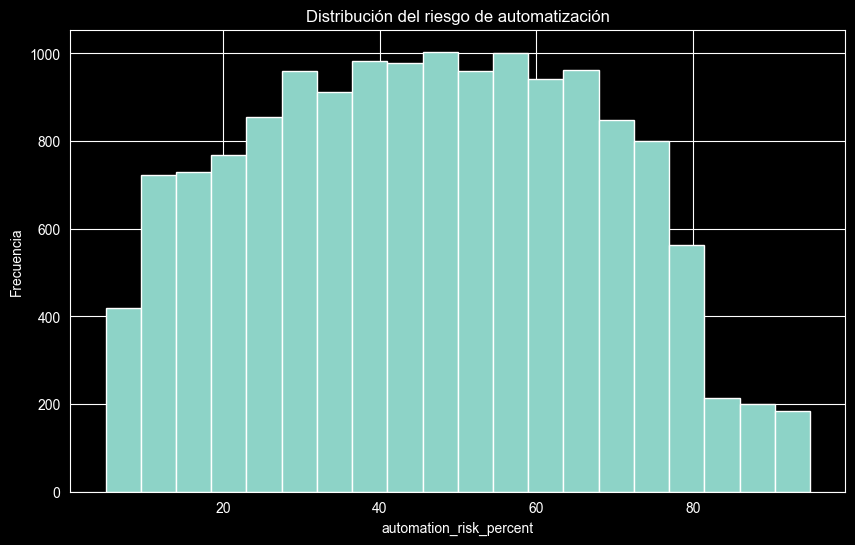

In [43]:

fig = plt.figure(figsize=(10,6))

plt.hist(data["automation_risk_percent"], bins = 20)

plt.xlabel("automation_risk_percent")
plt.ylabel("Frecuencia")
plt.title("Distribución del riesgo de automatización")
plt.show(fig)


In [44]:

#Seleccionar variables numéricas
variables_numericas = data.select_dtypes(include = [np.number])

variables_numericas.head()


,job_id,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,0,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,49.710,2.34,33.150,22.711764
1,1,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,27.070,4.69,22.857,9.551472
2,2,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,37.245,10.13,28.516,11.468320
3,3,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,38.445,5.44,30.391,9.704860
4,4,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,55.555,6.01,36.591,6.404910


In [45]:

#Separar respuesta y predictoras
respuesta = variables_numericas["ai_replacement_score"]

predictoras = variables_numericas.drop(["ai_replacement_score"],
                                      axis = 1)

#Estandarizar
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(predictoras)

predictoras_est = pd.DataFrame(scaler.transform(predictoras),
                              columns = predictoras.columns)

predictoras_est


,job_id,year,automation_risk_percent,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,-1.731935,-0.998951,-0.921222,0.805145,0.349574,0.266985,-0.244720,-0.237093,-1.533793,1.275885,-0.722667,0.089467,-0.930688,-0.218878,-0.016181
1,-1.731704,-1.499126,0.272523,-1.664130,1.640099,1.383035,-0.479044,0.543354,-1.103444,-1.090039,1.412454,-1.160881,-0.543344,-1.047888,-0.737623
2,-1.731473,-1.499126,-0.686720,-0.236504,-0.719095,-0.877560,-1.021479,0.313338,-0.719494,-0.455938,-0.722667,-0.598942,0.353317,-0.592106,-0.632542
3,-1.731243,-0.998951,0.495947,-1.042472,0.056104,-0.087890,-0.553828,0.109437,0.378225,-1.134738,1.412454,-0.532669,-0.419723,-0.441091,-0.729214
4,-1.731012,0.501576,-1.459931,1.615972,1.078657,0.822046,-0.610664,-0.295351,0.645018,-0.200219,-0.010960,0.412271,-0.325772,0.058265,-0.910116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,1.731012,1.001752,-0.098156,-1.698840,-0.443588,-0.370575,0.270792,-2.300208,1.610886,-1.450402,-1.434374,-1.410232,-0.849923,-1.375691,-1.069495
14996,1.731243,0.001400,-1.407768,-0.523210,0.230493,0.122672,-0.363378,1.317775,-0.659949,-0.935845,1.412454,-1.258357,-0.734544,-1.454380,-1.065335
14997,1.731473,1.501927,1.568748,-0.049764,-0.433653,-0.275261,0.680609,2.158489,-0.529645,-1.359272,-0.010960,0.898824,-0.172482,1.034908,-0.796749
14998,1.731704,-1.499126,-0.537155,-0.024426,1.009864,1.044893,0.207973,0.536323,1.438051,-1.629891,-0.010960,-0.340754,-0.953764,-0.531700,-1.208971


In [46]:

#División entrenamiento y validación
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(predictoras_est,
                                                    respuesta,
                                                    test_size = 0.25,
                                                    random_state = 2026)


In [47]:

#Modelo Ridge alpha = 1
ridge_reg = Ridge(alpha = 1, solver = "auto")

ridge_reg.fit(X_train, y_train)

print("El intercepto que se tiene es %s" %ridge_reg.intercept_)

coefs_ridge_a = pd.DataFrame({"Variables": predictoras.columns,
                              "Coeficientes": ridge_reg.coef_})

coefs_ridge_a


El intercepto que se tiene es 46.21992087247706


,Variables,Coeficientes
0,job_id,0.035009
1,year,0.043896
2,automation_risk_percent,15.561755
3,skill_gap_index,-7.050695
4,salary_before_usd,-0.128236
5,salary_after_usd,0.110885
6,salary_change_percent,-0.145384
7,skill_demand_growth_percent,0.081110
8,remote_feasibility_score,-0.015390
9,ai_adoption_level,0.197393


In [48]:

#Modelo Ridge alpha = 1000
ridge_reg_b = Ridge(alpha = 1000, solver = "auto")

ridge_reg_b.fit(X_train, y_train)

print("El intercepto que se tiene es %s" %ridge_reg_b.intercept_)

coefs_ridge_b = pd.DataFrame({"Variables": predictoras.columns,
                              "Coeficientes": ridge_reg_b.coef_})

coefs_ridge_b


El intercepto que se tiene es 46.214002435344426


,Variables,Coeficientes
0,job_id,0.027166
1,year,0.049676
2,automation_risk_percent,13.291023
3,skill_gap_index,-5.775640
4,salary_before_usd,0.018820
5,salary_after_usd,0.000256
6,salary_change_percent,-0.119418
7,skill_demand_growth_percent,0.069020
8,remote_feasibility_score,-0.009442
9,ai_adoption_level,-1.813929


In [49]:

#Modelo lineal
lm = LinearRegression()

lm.fit(X_train, y_train)

#Predicciones
y_pred_lm = lm.predict(X_test)

y_pred_ridge = ridge_reg.predict(X_test)

y_pred_ridge_b = ridge_reg_b.predict(X_test)

#Errores
mse_lm = mean_squared_error(y_test, y_pred_lm)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)

mse_ridge_b = mean_squared_error(y_test, y_pred_ridge_b)

comparacion_ridge = pd.DataFrame({"Modelo": ["Lineal",
                                            "Ridge 1",
                                            "Ridge 1000"],
                                 "MSE": [mse_lm,
                                        mse_ridge,
                                        mse_ridge_b]})

comparacion_ridge


,Modelo,MSE
0,Lineal,34.443157
1,Ridge 1,34.442300
2,Ridge 1000,36.559315


In [50]:

#Modelo Lasso alpha = 1
lasso_reg = Lasso(alpha = 1)

lasso_reg.fit(X_train, y_train)

#Modelo Lasso alpha = 10
lasso_reg_b = Lasso(alpha = 10)

lasso_reg_b.fit(X_train, y_train)

#Predicciones
y_pred_lasso = lasso_reg.predict(X_test)

y_pred_lasso_b = lasso_reg_b.predict(X_test)

#Errores
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

mse_lasso_b = mean_squared_error(y_test, y_pred_lasso_b)

comparacion_lasso = pd.DataFrame({"Modelo": ["Lineal",
                                            "Lasso 1",
                                            "Lasso 10"],
                                 "MSE": [mse_lm,
                                        mse_lasso,
                                        mse_lasso_b]})

comparacion_lasso


,Modelo,MSE
0,Lineal,34.443157
1,Lasso 1,34.892420
2,Lasso 10,130.747865


In [51]:
#Modelo Red Elástica r = 0.1
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV

e_net_a = ElasticNet(alpha = 1,
                     l1_ratio = 0.1,
                     random_state = 2026)

e_net_a.fit(X_train, y_train)

y_pred_elastic_a = e_net_a.predict(X_test)

mse_elastic_a = mean_squared_error(y_test, y_pred_elastic_a)

#Modelo Red Elástica r = 0.9
e_net_b = ElasticNet(alpha = 1,
                     l1_ratio = 0.9,
                     random_state = 2026)

e_net_b.fit(X_train, y_train)

y_pred_elastic_b = e_net_b.predict(X_test)

mse_elastic_b = mean_squared_error(y_test, y_pred_elastic_b)

#Modelo Red Elástica CV
modelo_cv = ElasticNetCV(l1_ratio = [0.1,0.3,0.5,0.7,0.9,1],
                         alphas = np.logspace(-3,4,100),
                         cv = 10,
                         random_state = 2026)

modelo_cv.fit(X_train, y_train)

e_net_cv = ElasticNet(alpha = modelo_cv.alpha_,
                      l1_ratio = modelo_cv.l1_ratio_,
                      random_state = 2026)

e_net_cv.fit(X_train, y_train)

y_pred_elastic_cv = e_net_cv.predict(X_test)

mse_elastic_cv = mean_squared_error(y_test, y_pred_elastic_cv)

print("El mejor valor de r es %s" %modelo_cv.l1_ratio_)
print("El mejor valor de alpha es %s" %modelo_cv.alpha_)


El mejor valor de r es 1.0
El mejor valor de alpha es 0.06892612104349695


In [53]:
#Modelo Red Elástica r = 0.1
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV

e_net_a = ElasticNet(alpha = 1,
                     l1_ratio = 0.1,
                     random_state = 2026)

e_net_a.fit(X_train, y_train)

y_pred_elastic_a = e_net_a.predict(X_test)

mse_elastic_a = mean_squared_error(y_test, y_pred_elastic_a)

#Modelo Red Elástica r = 0.9
e_net_b = ElasticNet(alpha = 1,
                     l1_ratio = 0.9,
                     random_state = 2026)

e_net_b.fit(X_train, y_train)

y_pred_elastic_b = e_net_b.predict(X_test)

mse_elastic_b = mean_squared_error(y_test, y_pred_elastic_b)

#Modelo Red Elástica CV
modelo_cv = ElasticNetCV(l1_ratio = [0.1,0.3,0.5,0.7,0.9,1],
                         alphas = np.logspace(-3,4,100),
                         cv = 10,
                         random_state = 2026)

modelo_cv.fit(X_train, y_train)

e_net_cv = ElasticNet(alpha = modelo_cv.alpha_,
                      l1_ratio = modelo_cv.l1_ratio_,
                      random_state = 2026)

e_net_cv.fit(X_train, y_train)

y_pred_elastic_cv = e_net_cv.predict(X_test)

mse_elastic_cv = mean_squared_error(y_test, y_pred_elastic_cv)

print("El mejor valor de r es %s" %modelo_cv.l1_ratio_)
print("El mejor valor de alpha es %s" %modelo_cv.alpha_)


El mejor valor de r es 1.0
El mejor valor de alpha es 0.06892612104349695


In [54]:
#Modelo final Red Elástica r = 0.9
e_net_c = ElasticNet(alpha = 1,
                     l1_ratio = 0.9,
                     random_state = 2026)

e_net_c.fit(X_train, y_train)

#Obtener medianas
medianas = np.median(X_train, axis = 0)

#Predicción final
prediccion = e_net_c.predict(medianas.reshape(1,-1))

prediccion


C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but ElasticNet was fitted with feature names


array([46.10212735])